In [1]:
# Habilita a renderização nativa de gráficos vetoriais leves e nítidos (SVG) no Jupyter
%config InlineBackend.figure_formats = ['svg']

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import windIO
from shapely.geometry import Point, Polygon

# Importações da API do optiwindnet
from optiwindnet.api import WindFarmNetwork, MILPRouter, ModelOptions

# Configuração de caminhos (ajuste se os arquivos estiverem em outra pasta)
SCRIPT_DIR = Path(".")
SYSTEM_YAML_PATH = SCRIPT_DIR / "Data" / "vineyard_revolution_system.yaml"
SITE_YAML_PATH = SCRIPT_DIR / "Data" / "site_us.yaml"

print("--> Ambiente configurado com suporte a SVG nativo.")

--> Ambiente configurado com suporte a SVG nativo.


In [2]:
print("=== 1. PREPARANDO MATRIZ DE CABOS ===")
cable_specs = np.array(
    list(zip([3, 5, 7], [368.9, 428.9, 737.1])), 
    dtype=[("capacity", int), ("cost", float)]
)

print("\n=== 2. CARREGANDO E FILTRANDO COORDENADAS REAIS ===")
site_dat = windIO.load_yaml(SITE_YAML_PATH)
revolution_poly_dat = site_dat['boundaries']['polygons'][1]
boundary_vertices = np.column_stack((revolution_poly_dat['x'], revolution_poly_dat['y']))

shapely_boundary = Polygon(boundary_vertices)

system_dat = windIO.load_yaml(SYSTEM_YAML_PATH)
revolution_data = system_dat['wind_farm'][1]
print(f"Parque Escolhido: {revolution_data['name']}")

# Filtragem das 66 turbinas internas do Revolution Wind
x_raw = np.array(revolution_data['layouts'][0]['coordinates']['x'], dtype=float)
y_raw = np.array(revolution_data['layouts'][0]['coordinates']['y'], dtype=float)

x_filtrado, y_filtrado = [], []
for x_val, y_val in zip(x_raw, y_raw):
    ponto_wt = Point(x_val, y_val)
    if shapely_boundary.contains(ponto_wt) or ponto_wt.distance(shapely_boundary) < 1.0:
        x_filtrado.append(x_val)
        y_filtrado.append(y_val)

turbines_coord = np.column_stack((x_filtrado, y_filtrado))
print(f"--> [Filtro Aplicado] Turbinas DENTRO da Boundary: {len(turbines_coord)}")

# Extração dinâmica de múltiplas subestações
substations_list = []
electrical_substations = revolution_data.get('electrical_substations', [])

for idx, sub_item in enumerate(electrical_substations):
    sub_coords = sub_item['electrical_substation']['coordinates']
    substations_list.append([float(sub_coords['x'][0]), float(sub_coords['y'][0])])
    print(f"--> [OSS {idx}] Carregada em X: {substations_list[-1][0]}, Y: {substations_list[-1][1]}")

substation_coord = np.array(substations_list, dtype=float)

=== 1. PREPARANDO MATRIZ DE CABOS ===

=== 2. CARREGANDO E FILTRANDO COORDENADAS REAIS ===
Parque Escolhido: Revolution Wind
--> [Filtro Aplicado] Turbinas DENTRO da Boundary: 66
--> [OSS 0] Carregada em X: 321455.0, Y: 4564293.0
--> [OSS 1] Carregada em X: 327170.0, Y: 4555050.0


In [3]:
print("\n=== 3. CONFIGURANDO O MODELO MATEMÁTICO RADIAL ===")
model_opts = ModelOptions(
    topology='radial',         # Reduz cruzamentos forçando strings radiais limpas[cite: 4]
    feeder_limit='minimum',    # Equilibra ramais entre as subestações
    feeder_route='segmented'   # Permite quebrar trajetórias nas quinas do lease[cite: 4]
)

# Inicializa o router exato via OR-Tools CP-SAT[cite: 1, 4]
router = MILPRouter(
    solver_name='ortools.cp_sat',
    time_limit=90,             # Tempo estendido para acomodar o cálculo de rotas segmentadas
    mip_gap=0.005,             # Tolerância fina de 0.5%[cite: 1]
    model_options=model_opts,
    verbose=True
)

wfn = WindFarmNetwork(
    turbinesC=turbines_coord,
    substationsC=substation_coord,
    cables=cable_specs,
    borderC=boundary_vertices
)

# Prepara os caminhos lineares costurando os limites da cerca[cite: 4]
wfn.merge_obstacles_into_border()
wfn.add_buffer(buffer_dist=0.5)

print("\n=== 4. EXECUTANDO ROTEAMENTO EXACT MILP ===")
wfn.optimize(router=router)

print(f"\n--> Otimização Concluída!")
print(f"--> Comprimento Total da Rede: {wfn.length():,.2f} metros")
print(f"--> Custo Total de Aquisição:  ${wfn.cost():,.2f} USD")


=== 3. CONFIGURANDO O MODELO MATEMÁTICO RADIAL ===


The defined border is non-convex and buffering may introduce unexpected changes. For visual comparison use plot_original_vs_buffered().



=== 4. EXECUTANDO ROTEAMENTO EXACT MILP ===

Running basic LP presolve, initial problem dimensions: 2081 rows, 1360 columns, 7990 entries with magnitude in [1.000000e+00, 7.000000e+00]
glop::FixedVariablePreprocessor                        2081 rows, 1360 columns, 7990 entries with magnitude in [1.000000e+00, 7.000000e+00]
glop::SingletonPreprocessor                            2081 rows, 1360 columns, 7990 entries with magnitude in [1.000000e+00, 7.000000e+00]
glop::ForcingAndImpliedFreeConstraintPreprocessor      2081 rows, 1360 columns, 7990 entries with magnitude in [1.000000e+00, 7.000000e+00]
glop::FreeConstraintPreprocessor                       2081 rows, 1360 columns, 7990 entries with magnitude in [1.000000e+00, 7.000000e+00]
glop::UnconstrainedVariablePreprocessor                2081 rows, 1360 columns, 7990 entries with magnitude in [1.000000e+00, 7.000000e+00]
IntegerBoundsPreprocessor                              2081 rows, 1360 columns, 7990 entries with magnitude in [1.

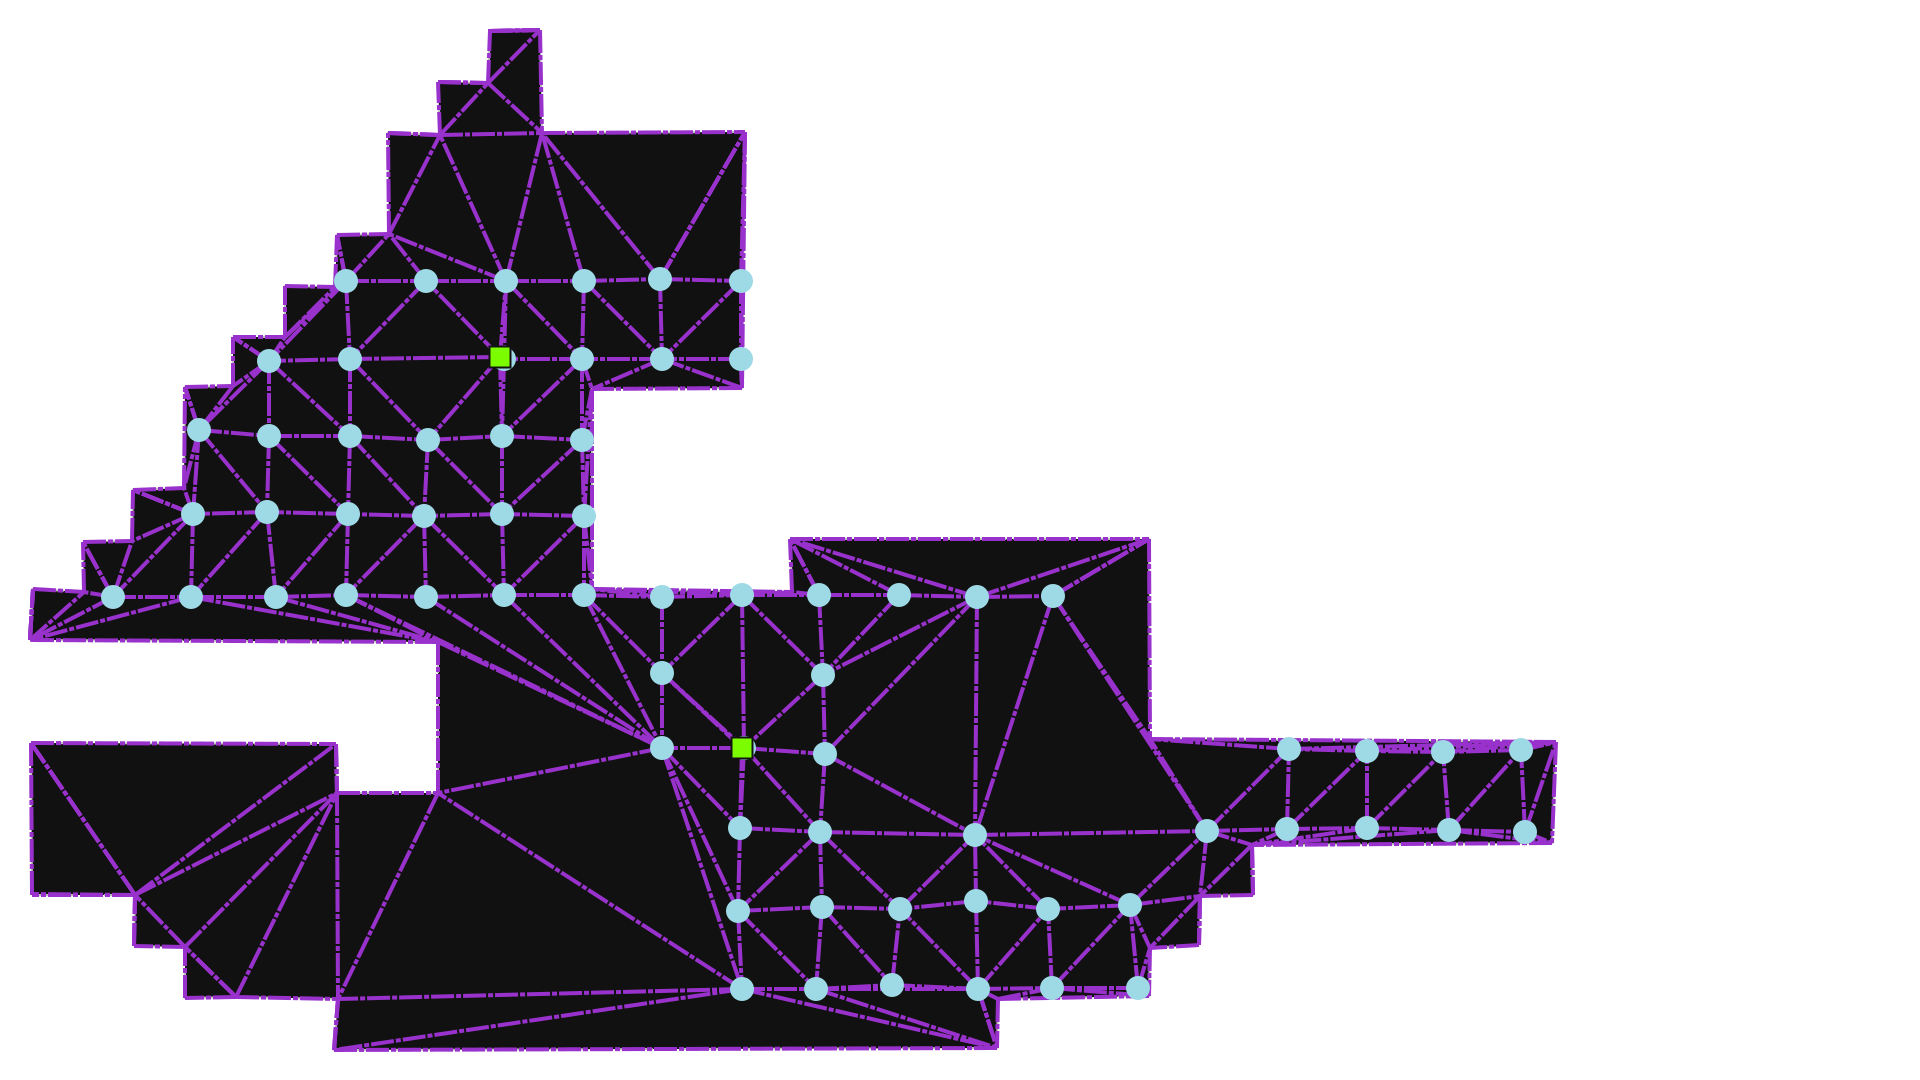

In [4]:
wfn.plot_navigation_mesh(dark=True, landscape=False)

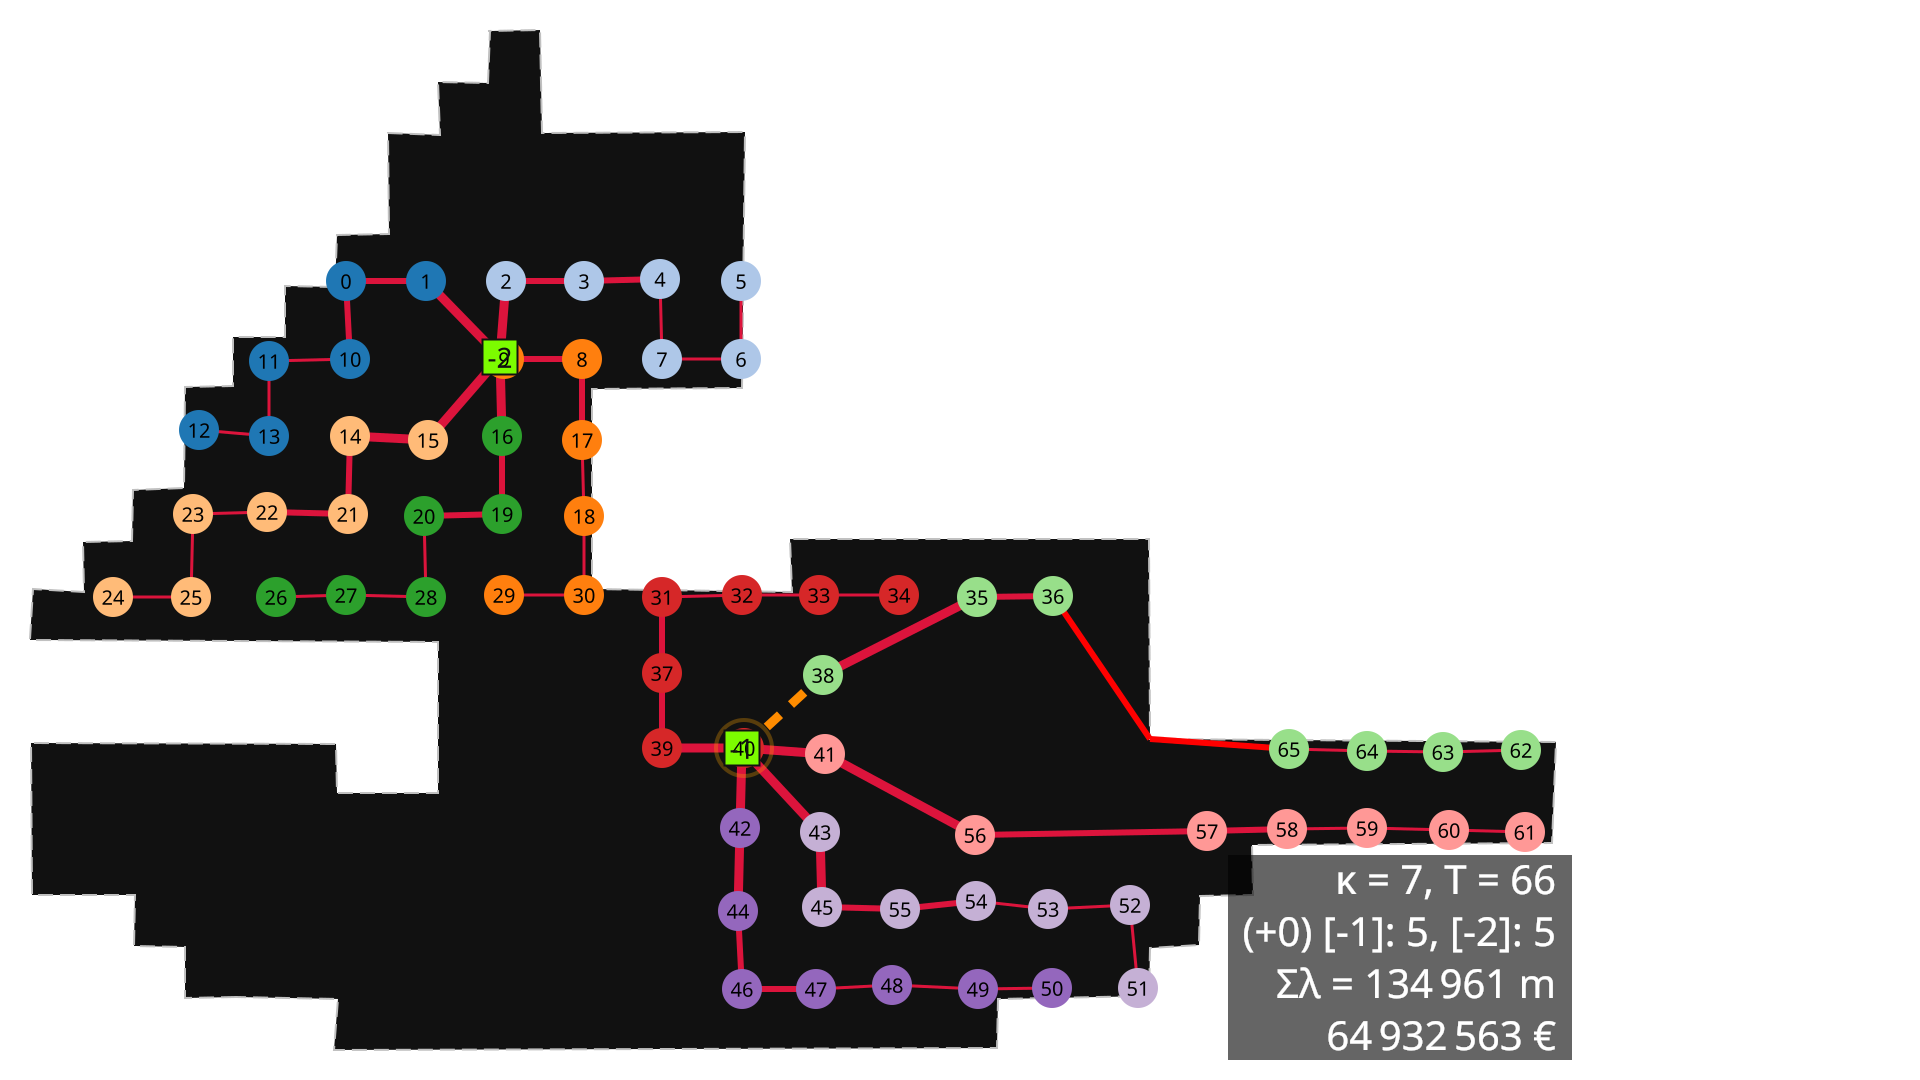

In [5]:
wfn.plot(node_tag=True, dark=True, landscape=False)

=== 6. EXPORTANDO PARA MATPLOTLIB BACKEND (OPCIONAL) ===


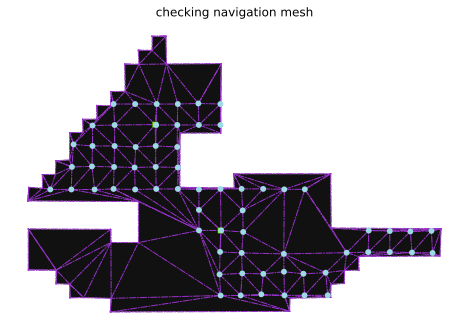

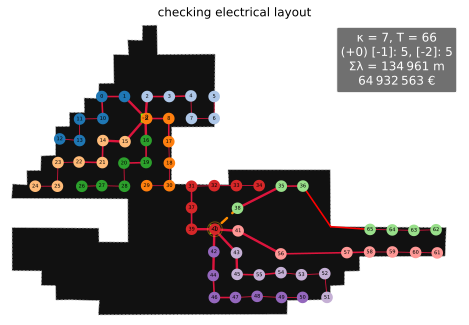

In [15]:
print("=== 6. EXPORTANDO PARA MATPLOTLIB BACKEND (OPCIONAL) ===")

# Passando ax=None o pacote converte o grafo do NetworkX para coordenadas Matplotlib automaticamente
fig_mesh = wfn.plot_navigation_mesh(ax=None, dark=True, landscape=False)
fig_mesh.set_title("checking navigation mesh")

fig_network = wfn.plot(ax=None, node_tag=True, dark=True, landscape=False)
fig_network.set_title("checking electrical layout")

# O show do pyplot exibe os plots gerados pelo backend gplot/pplot
plt.show()

In [13]:
print("=== DEBUG DE ESTRUTURA DO OPTIWINDNET ===")

# 1. Investigando o wfn.get_network() que usamos originalmente
edges_array = wfn.get_network()
print(f"\ntype(wfn.get_network()): {type(edges_array)}")
print(f"Número de conexões exportadas pelo array: {len(edges_array)}")
print("Amostra das 3 primeiras conexões do array:")
for edge in edges_array[:3]:
    print("  ->", dict(zip(edges_array.dtype.names, edge)))

# 2. Investigando o Grafo de Rotas wfn.G (O cérebro que o plot nativo usa)
print(f"\ntype(wfn.G): {type(wfn.G)}")
print(f"Número de nós no Grafo G: {wfn.G.number_of_nodes()}")
print(f"Número de arestas no Grafo G: {wfn.G.number_of_edges()}")

# 3. Vamos olhar os metadados globais guardados dentro de wfn.G
print("\nAtributos globais do Grafo (wfn.G.graph):")
for k, v in wfn.G.graph.items():
    # Escondemos matrizes gigantes para não inundar o terminal
    if isinstance(v, np.ndarray) and v.size > 10:
        print(f"  {k}: Array NumPy de formato {v.shape}")
    else:
        print(f"  {k}: {v}")

# 4. Raio-X de uma única Aresta/Cabo de wfn.G para ver os dicionários internos
print("\nEspionando os dados brutos armazenados nas arestas de wfn.G:")
sample_edges = list(wfn.G.edges(data=True))[:3]
for idx, (u, v, data) in enumerate(sample_edges):
    print(f"  Aresta {idx} (Nó {u} -> Nó {v}):")
    print(f"    Conteúdo do dicionário de dados: {data}")

# 5. Espionando o formato de armazenamento dos nós de wfn.G
print("\nEspionando o formato de armazenamento de coordenadas nos nós de wfn.G:")
sample_nodes = list(wfn.G.nodes(data=True))[:5]
for node, data in sample_nodes:
    print(f"  Nó {node}: {data}")

=== DEBUG DE ESTRUTURA DO OPTIWINDNET ===

type(wfn.get_network()): <class 'numpy.ndarray'>
Número de conexões exportadas pelo array: 68
Amostra das 3 primeiras conexões do array:
  -> {'src': np.int64(1), 'tgt': np.int64(-2), 'length': np.float64(2503.3863533106673), 'load': np.float64(6.0), 'cable': np.int64(2)}
  -> {'src': np.int64(16), 'tgt': np.int64(-2), 'length': np.float64(1866.0385836639414), 'load': np.float64(6.0), 'cable': np.int64(2)}
  -> {'src': np.int64(9), 'tgt': np.int64(-2), 'length': np.float64(98.76226075259108), 'load': np.float64(6.0), 'cable': np.int64(2)}

type(wfn.G): <class 'networkx.classes.graph.Graph'>
Número de nós no Grafo G: 70
Número de arestas no Grafo G: 68

Atributos globais do Grafo (wfn.G.graph):
  R: 2
  T: 66
  capacity: 7
  max_load: 7
  has_loads: True
  creator: MILP.ortools.cp_sat
  solver_details: {'max_feeders': 0, 'strategy': 'OPTIMAL'}
  B: 113
  border: Array NumPy de formato (113,)
  name: 
  handle: 
  norm_scale: 7.163382713907338e-

=== 1. PREPARANDO MATRIZ DE CABOS ===
=== 1. PREPARANDO MATRIZ DE CABOS ===

=== 2. CARREGANDO E FILTRANDO COORDENADAS REAIS ===
Parque Escolhido: Revolution Wind

=== 6. PLOT CUSTOMIZADO HISTÓRICO CORRIGIDO (MATPLOTLIB) ===


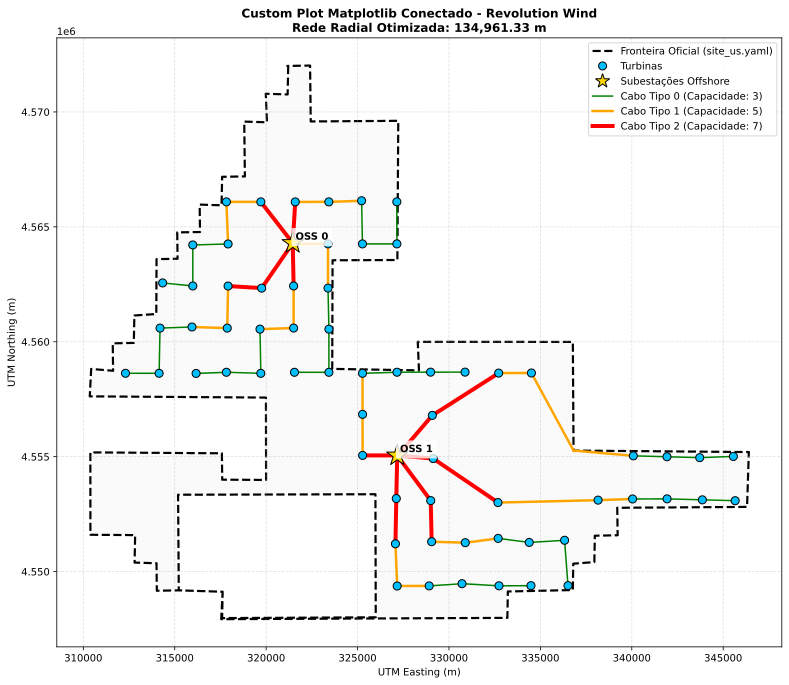

In [14]:
from pathlib import Path
import numpy as np
import windIO
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt

# CORREÇÃO DE CAMINHO: Usamos caminhos absolutos baseados na estrutura real que o terminal denunciou
BASE_DIR = Path("/Users/brunoboer/Documents/Software/Test_Wesl_jun23/wesl/Advanced_Optimizer")
SYSTEM_YAML_PATH = BASE_DIR / "Data" / "vineyard_revolution_system.yaml"
SITE_YAML_PATH = BASE_DIR / "Data" / "site_us.yaml"

# Caso a sua pasta 'Data' esteja um nível acima (na raiz da pasta wesl/), use esta alternativa:
if not SITE_YAML_PATH.exists():
    BASE_DIR = Path("/Users/brunoboer/Documents/Software/Test_Wesl_jun23/wesl")
    SYSTEM_YAML_PATH = BASE_DIR / "Data" / "vineyard_revolution_system.yaml"
    SITE_YAML_PATH = BASE_DIR / "Data" / "site_us.yaml"

print("=== 1. PREPARANDO MATRIZ DE CABOS ===")
print("=== 1. PREPARANDO MATRIZ DE CABOS ===")
cable_specs = np.array(
    list(zip([3, 5, 7], [368.9, 428.9, 737.1])), 
    dtype=[("capacity", int), ("cost", float)]
)

print("\n=== 2. CARREGANDO E FILTRANDO COORDENADAS REAIS ===")
site_dat = windIO.load_yaml(SITE_YAML_PATH)
revolution_poly_dat = site_dat['boundaries']['polygons'][1]
boundary_vertices = np.column_stack((revolution_poly_dat['x'], revolution_poly_dat['y']))
boundary_closed = np.vstack([boundary_vertices, boundary_vertices[0]])

shapely_boundary = Polygon(boundary_vertices)

system_dat = windIO.load_yaml(SYSTEM_YAML_PATH)
revolution_data = system_dat['wind_farm'][1]
print(f"Parque Escolhido: {revolution_data['name']}")
print("\n=== 6. PLOT CUSTOMIZADO HISTÓRICO CORRIGIDO (MATPLOTLIB) ===")

# 1. Puxamos os elementos mestre de geometria de dentro do grafo de rotas (wfn.G)
vertex_matrix = wfn.G.graph['VertexC']  # Matriz real contendo TODOS os pontos (181, 2)
node_mapper = wfn.G.graph['fnT']       # Vetor mapeador de índices do NetworkX para a matriz[cite: 4]
edges_list = wfn.get_network()          # Lista de conexões elétricas compactas[cite: 4]

# 2. Construímos o dicionário de posições perfeito usando a regra interna do pacote
pos_dict = {}

# Varremos todos os nós lógicos que existem no grafo de rotas
for node in wfn.G.nodes():
    # O mapeador fnT traduz o ID do nó para a linha correspondente na matriz mestre[cite: 4]
    matrix_index = node_mapper[node]
    pos_dict[node] = (vertex_matrix[matrix_index, 0], vertex_matrix[matrix_index, 1])

# 3. Inicializando a figura clássica do Matplotlib
plt.figure(figsize=(13, 11))

# Desenha a Fronteira Oficial recortada em escada
plt.plot(boundary_closed[:, 0], boundary_closed[:, 1], color='black', linestyle='--', linewidth=2.2, label='Fronteira Oficial (site_us.yaml)', zorder=1)
plt.fill(boundary_vertices[:, 0], boundary_vertices[:, 1], color='grey', alpha=0.04, zorder=0)

# Desenha as turbinas válidas filtradas como os círculos azuis
plt.scatter(turbines_coord[:, 0], turbines_coord[:, 1], color='deepskyblue', s=65, edgecolor='black', label='Turbinas Ativas Internas', zorder=4)

# 4. Loop de plotagem dos cabos com as NOSSAS cores e bitolas históricas
for edge in edges_list:
    src_idx = int(edge['src'])
    tgt_idx = int(edge['tgt'])
    cable_type = edge['cable']
    
    # Busca a coordenada exata de origem traduzida da matriz mestre
    x0, y0 = pos_dict[src_idx]
    
    # Busca a coordenada exata de destino traduzida da matriz mestre
    x1, y1 = pos_dict[tgt_idx]
    
    # Aplica as bitolas e cores históricas
    if cable_type == 0:
        line_color, line_width = 'green', 1.5
    elif cable_type == 1:
        line_color, line_width = 'orange', 2.5
    else:
        line_color, line_width = 'red', 4.0
        
    plt.plot([x0, x1], [y0, y1], color=line_color, linewidth=line_width, zorder=3)

# 5. Desenha as duas Subestações Offshore Reais como estrelas douradas gigantes
for idx, (sub_x, sub_y) in enumerate(substation_coord):
    plt.scatter(sub_x, sub_y, color='gold', marker='*', s=500, edgecolor='black', 
                label='Subestação Offshore (OSS)' if idx == 0 else "", zorder=5)
    plt.text(sub_x + 150, sub_y + 150, f"OSS {idx}", fontsize=10, fontweight='bold', 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'), zorder=6)

# 6. Títulos, Labels de eixos UTM e Gradeamento real
plt.title(f"Custom Plot Matplotlib Conectado - {revolution_data['name']}\nRede Radial Otimizada: {wfn.length():,.2f} m", fontsize=12, fontweight='bold')
plt.xlabel("UTM Easting (m)")
plt.ylabel("UTM Northing (m)")
plt.grid(True, linestyle="--", alpha=0.4)

# Legenda customizada estruturada
from matplotlib.lines import Line2D
custom_legend = [
    Line2D([0], [0], color='black', linestyle='--', linewidth=2.2, label='Fronteira Oficial (site_us.yaml)'),
    Line2D([0], [0], color='deepskyblue', marker='o', linestyle='', markersize=8, markeredgecolor='black', label='Turbinas'),
    Line2D([0], [0], color='gold', marker='*', linestyle='', markersize=15, markeredgecolor='black', label='Subestações Offshore'),
    Line2D([0], [0], color='green', linewidth=1.5, label='Cabo Tipo 0 (Capacidade: 3)'),
    Line2D([0], [0], color='orange', linewidth=2.5, label='Cabo Tipo 1 (Capacidade: 5)'),
    Line2D([0], [0], color='red', linewidth=4.0, label='Cabo Tipo 2 (Capacidade: 7)')
]
plt.legend(handles=custom_legend, loc="upper right")

plt.show()